# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2025-2
## ARBOLES DE DECISIÓN
## LABORATORIO 2/4

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando árboles de decisión
2. Implementar árboles de decisión
3. Apropiar un framework para árboles de decisión (*scikit-learn*)
4. Conocer una librería para procesamiento de datos simbólicos (*python pandas DataFrame*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Este laboratorio se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
Incluyan en un archivo *.zip* los archivos correspondientes al laboratorio.

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “DT-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# **PARTE I. IMPLEMENTACIÓN DE ÁRBOLES DE DECISIÓN**
Para este apartado se van a implementar un árbol de decisión, en este caso usando como medida la entropia.

*La idea de los árboles de decisión fue desarrollada paulatinamiente. El pionero más reconocido es Ross Quinlan, quien propuso en 1986 el algoritmo ID3 (Iterative Dichotomiser 3) en el artículo [Induction of decision trees](https://link.springer.com/article/10.1007/BF00116251). Este algoritmo marcó un hito en la construcción automática de árboles de decisión a partir de datos.*

## I.A. IMPLEMENTACIÓN DE UN ÁRBOL DE DECISIÓN

Implementar un árbol de decisión; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades:**

*   Tarea: **Clasificación binaria**
*   Características: **Categóricas**
*   Criterio de selección: **Ganancia de información**
*   Métrica para evaluación : **F1 SCORE**

<div>
<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/09/Precision-vs-Recall-in-Machine-Learning.webp" width="350"/>
</div>

> **Formulas**

*   Impureza : **Entropía: H**

*   Ganancia de información: **IG(D,A)**

*   Impureza de Arbol: **Impurity(V\*)**







## Paso 1. Criterios de selección de atributos
Las impurezas en árboles de decision miden cuán homogéneas o heterogéneas son las clases dentro de un conjunto de datos ***en un nodo del árbol***. La métrica de impureza determina cómo dividir los datos en cada nodo.
Los principales métodos de evaluación de impureza son: **entropía** e **indice gini**.

*Incluyan las formulas de los dos criterios de selección y comparelos considerando criterios como sensibilidad al desbalance de clases y eficiencia computacional*

---
**Entropia:**
- La fórmula de la Entropía ($H(S)$) para un conjunto de datos $S$ con $c$ clases es:

  $$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

- Donde:
  - $c$ es el número de clases únicas.
  - $p_i$ es la proporción (probabilidad) de muestras que pertenecen a la clase $i$ en el nodo $S$.

---
**Gini**
- La fórmula del Índice Gini ($G(S)$) para un conjunto de datos $S$ con $c$ clases es:

$$G(S) = 1 - \sum_{i=1}^{c} (p_i)^2$$

- Donde:
  - $c$ es el número de clases únicas.
  - $p_i$ es la proporción (probabilidad) de muestras que pertenecen a la clase $i$ en el nodo $S$.

---
**Comparación**
- 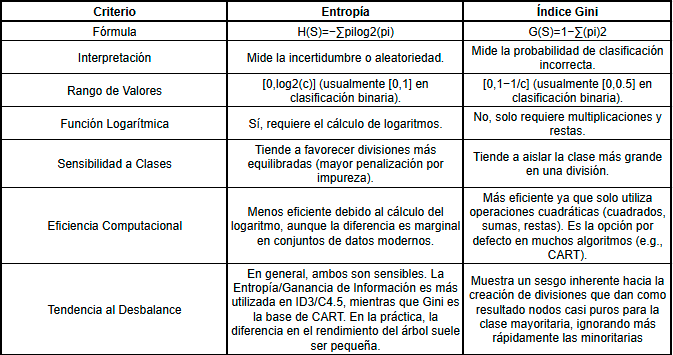

- 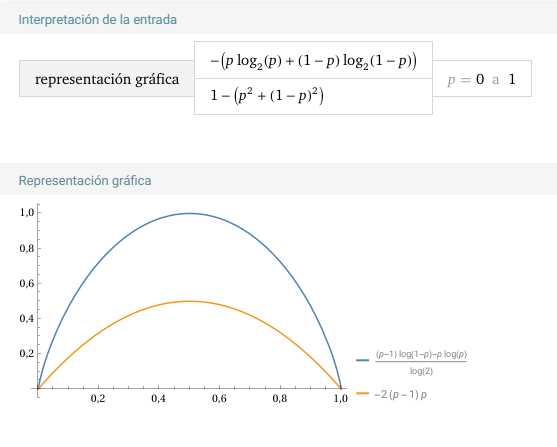

## Paso 2. Ganancia de una característica e impureza del árbol
Los otros dos conceptos de fundamentan los árboles de decisión son la **ganancia de información** y la **impureza *de un arbol***.

*Expliquen su proposito y la fórmula correspondiente, detallandola.*

---
**Ganancia:**

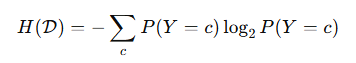

La ganancia de información mide la reducción de incertidumbre (o impureza) en un conjunto de datos al dividirlo con base en un atributo específico. En los árboles de decisión, este criterio se utiliza para seleccionar el atributo que mejor separa las clases en cada nodo.

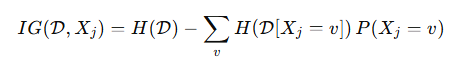

Esta es la forma general para la ganancia de información y es esta la formula que usaremos para calcularla. Nos indica que cuanto mayor sea la ganancia de información, más útil será el atributo para dividir el conjunto de datos, ya que produce nodos con clases más homogéneas.


---
**Impureza**

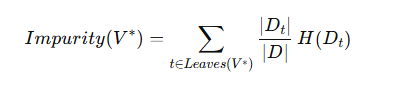

Por otro lado, esta formula mide el grado de desorden total del árbol de decisión completo, considerando todas sus hojas. Permite evaluar la calidad global del modelo, ya que un árbol con impureza baja clasifica mejor los datos, pues sus hojas contienen ejemplos predominantemente de una sola clase.

Vemos que V* es el arbol de decisión final. Leaves(V*) es el conjunto de nodos hoja. D es el subconjunto de datos en la hoja t, y H(𝐷𝑡) es la entropía de dicha hoja.

El objetivo durante la construcción del árbol es maximizar la ganancia de información en cada división y, consecuentemente, minimizar la impureza total del árbol.

## Paso 3. Implementación del código base para un árbol de decisión

### Librería necesaria

In [ ]:
import pandas as pd
import numpy as np
from abc import ABC, abstractmethod
from typing import Sequence
from typing import List

### Funciones base: métrica y criterio

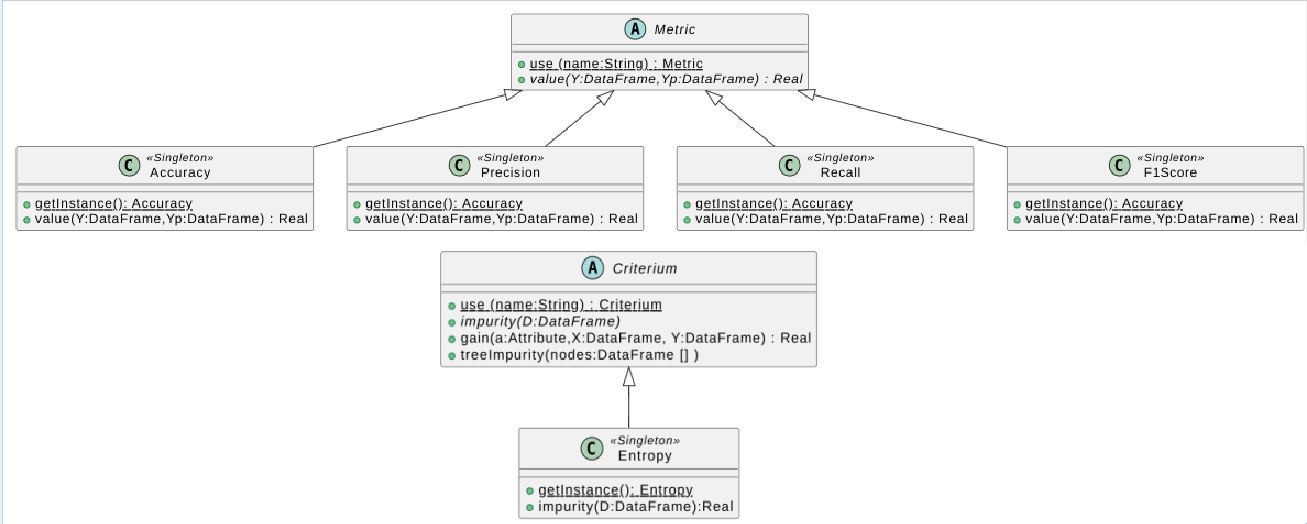

###Métrica

In [ ]:
class Metric(ABC):
    """Clase abstracta que define la estructura base para cualquier métrica de desempeño.
    Representa una métrica P utilizada para evaluar una tarea T.
    """
    @classmethod
    def use(cls, name: str):
        """Retorna una instancia de la métrica correspondiente al nombre dado.
        Args:name (str): nombre de la métrica ("accuracy", "precision", "recall", "f1score")
        Returns:Metric: instancia del tipo de métrica solicitada
        """
        name = name.lower()
        if name == "accuracy":
            return Accuracy.getInstance()
        elif name == "precision":
            return Precision.getInstance()
        elif name == "recall":
            return Recall.getInstance()
        elif name == "f1score":
            return F1Score.getInstance()
        else:
            raise ValueError(f"Métrica '{name}' no reconocida.")

    @abstractmethod
    def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        """Calcula el valor de la métrica.
        Args:Y (pd.DataFrame): valores esperados (etiquetas reales)
             Yp (pd.DataFrame): valores predichos por el modelo
        Returns: float: valor numérico de la métrica"""
        pass

In [ ]:
class Accuracy(Metric):
    """
    Métrica de exactitud (Accuracy).
    Calcula la proporción de predicciones correctas entre el total de predicciones.
    Implementa la clase abstracta Metric utilizando el patrón Singleton.
    """

    instancia = None

    def __new__(cls):
        """
        Implementa el patrón Singleton.
        Si no existe una instancia previa, crea una nueva.
        Si ya existe, retorna la instancia existente.
        """
        if cls.instancia is None:
            cls.instancia = super(Accuracy, cls).__new__(cls)
        return cls.instancia

    @classmethod
    def getInstance(cls):
        """
        Retorna la instancia única de la métrica Accuracy.
        """
        return cls()

    def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        """ Calcula la exactitud del modelo
        Fórmula:Accuracy = (número de aciertos) / (total de ejemplos
        Args: Y (pd.DataFrame): valores reales (etiquetas verdaderas)
              Yp (pd.DataFrame): valores predichos por el modelo
        Returns: float: valor numérico de la exactitud (entre 0 y 1) """
        correctos = (Y.values == Yp.values).sum()
        total = Y.size
        return correctos / total if total > 0 else 0.0


In [ ]:
class Precision(Metric):
    """Métrica de precisión. Implementa Metric."""
    instancia = None

    def __new__(cls):
        if cls.instancia is None:
            cls.instancia = super(Precision, cls).__new__(cls)
        return cls.instancia

    @classmethod
    def getInstance(cls):
        return cls()

    def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        tp = ((Y.values == 1) & (Yp.values == 1)).sum()
        fp = ((Y.values == 0) & (Yp.values == 1)).sum()
        return tp / (tp + fp) if (tp + fp) > 0 else 0.0

In [ ]:
class Recall(Metric):
    """Métrica de exhaustividad (Recall). Implementa Metric."""
    instancia = None

    def __new__(cls):
        if cls.instancia is None:
            cls.instancia = super(Recall, cls).__new__(cls)
        return cls.instancia

    @classmethod
    def getInstance(cls):
        """Retorna la instancia única de la métrica Recall."""
        return cls()

    def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        """Calcula la exhaustividad (Recall).
           Fórmula: Recall = TP / (TP + FN) """
        tp = ((Y.values == 1) & (Yp.values == 1)).sum()
        fn = ((Y.values == 1) & (Yp.values == 0)).sum()
        return tp / (tp + fn) if (tp + fn) > 0 else 0.0

In [ ]:
class F1Score(Metric):
    """Métrica F1: media armónica entre Precisión y Exhaustividad. Implementa Metric."""
    instancia = None

    def __new__(cls):
        if cls.instancia is None:
            cls.instancia = super(F1Score, cls).__new__(cls)
        return cls.instancia

    @classmethod
    def getInstance(cls):
        """Retorna la instancia única de la métrica F1Score."""
        return cls()

    def value(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        """Calcula la métrica F1Score.
           Fórmula: F1 = 2 * (Precision * Recall) / (Precision + Recall)
        """
        precision = Precision.getInstance().value(Y, Yp)
        recall = Recall.getInstance().value(Y, Yp)
        return (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

In [ ]:
import unittest
import pandas as pd

class TestMetrics(unittest.TestCase):
    def setUp(self):
        self.Y = pd.DataFrame([1, 0, 1, 1, 0])
        self.Yp_correctas = pd.DataFrame([1, 0, 1, 1, 0])
        self.Yp_incorrectas = pd.DataFrame([0, 1, 0, 0, 1])
        self.Yp_mixtas = pd.DataFrame([1, 1, 1, 0, 0])

    def test_Calculo_de_accuracy(self):
        valor = Accuracy.getInstance().value(self.Y, self.Yp_mixtas)
        self.assertAlmostEqual(valor, 3/5, places=6)

    def test_Calculo_de_precision(self):
        valor = Precision.getInstance().value(self.Y, self.Yp_mixtas)
        # TP = 2, FP = 1 → precision = 2 / (2 + 1) = 0.6667
        self.assertAlmostEqual(valor, 2/3, places=6)

    def test_Calculo_de_recall(self):
        """Prueba de cálculo de Recall."""
        valor = Recall.getInstance().value(self.Y, self.Yp_mixtas)
        # TP = 2, FN = 1 → recall = 2 / (2 + 1) = 0.6667
        self.assertAlmostEqual(valor, 2/3, places=6)

    def test_Calculo_de_f1score(self):
        valor = F1Score.getInstance().value(self.Y, self.Yp_mixtas)
        # F1 = 2 * (0.6667 * 0.6667) / (0.6667 + 0.6667) = 0.6667
        self.assertAlmostEqual(valor, 2/3, places=6)

    def test_metricas_perfectas(self):
        for metric in [Accuracy, Precision, Recall, F1Score]:
            valor = metric.getInstance().value(self.Y, self.Yp_correctas)
            self.assertEqual(valor, 1.0)

    def test_Verifica_las_metricas_valor_en_0(self):
        for metric in [Accuracy, Precision, Recall, F1Score]:
            valor = metric.getInstance().value(self.Y, self.Yp_incorrectas)
            self.assertEqual(valor, 0.0)

if __name__ == "__main__":
    suite = unittest.TestLoader().loadTestsFromTestCase(TestMetrics)
    unittest.TextTestRunner(verbosity=2).run(suite)

test_Calculo_de_accuracy (__main__.TestMetrics.test_Calculo_de_accuracy) ... ok
test_Calculo_de_f1score (__main__.TestMetrics.test_Calculo_de_f1score) ... ok
test_Calculo_de_precision (__main__.TestMetrics.test_Calculo_de_precision) ... ok
test_Calculo_de_recall (__main__.TestMetrics.test_Calculo_de_recall)
Prueba de cálculo de Recall. ... ok
test_Verifica_las_metricas_valor_en_0 (__main__.TestMetrics.test_Verifica_las_metricas_valor_en_0) ... ok
test_metricas_perfectas (__main__.TestMetrics.test_metricas_perfectas) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.022s

OK


###Criterio

In [ ]:

class Criterium(ABC):
    """Abstracta: Define el criterio para seleccionar y dar prioridad a los atributos.
    Representa la impureza.
    """

    @classmethod
    def use(cls, name: str):
        """Obtiene criterio de selección (OBJ) a partir del nombre."""
        name = name.lower()
        if name == "entropy":
            return Entropy.getInstance()
        else:
            raise ValueError(f"Criterio '{name}' no reconocido.")

    @abstractmethod
    def impurity(self, V: pd.DataFrame) -> float:
        pass

    @abstractmethod
    def gain(self, a: str, X: pd.DataFrame, Y: pd.DataFrame) -> float:
        pass

    @abstractmethod
    def treeImpurity(self, nodes: list[pd.DataFrame]) -> float:
        pass


In [ ]:
class Entropy(Criterium):
    """ Criterio de selección - impureza por entropía. """

    instancia = None

    def __new__(cls):
        """Implementa el patrón Singleton."""
        if cls.instancia is None:
            cls.instancia = super(Entropy, cls).__new__(cls)
        return cls.instancia

    @classmethod
    def getInstance(cls):
        """Retorna la instancia única del criterio de entropía."""
        return cls()

    def impurity(self, V: pd.DataFrame) -> float:
        """Calcula la entropía del conjunto de datos.
           Fórmula: H = -∑ p_i * log2(p_i)
        """
        if len(V) == 0:
            return 0.0
        data = V.iloc[:, 0] if isinstance(V, pd.DataFrame) else V
        valores, conteos = np.unique(data, return_counts=True)
        p = conteos / conteos.sum()
        return -np.sum(p * np.log2(p + 1e-9))

    def gain(self, a: str, X: pd.DataFrame, Y: pd.DataFrame) -> float:
        """Calcula la ganancia de información para el atributo 'a'.
           Fórmula: Gain = H(Y) - ∑( |Y_i| / |Y| * H(Y_i) )
        """
        total_entropy = self.impurity(Y)
        weighted_entropy = 0.0
        for valor in X[a].unique():
            subset = Y[X[a] == valor]
            weighted_entropy += (len(subset) / len(Y)) * self.impurity(subset)
        return total_entropy - weighted_entropy

    def treeImpurity(self, nodes: list[pd.DataFrame]) -> float:
        """Calcula la impureza total del árbol como suma ponderada de la impureza de cada nodo."""
        total = sum(len(n) for n in nodes)
        if total == 0:
            return 0.0
        return sum((len(n) / total) * self.impurity(n) for n in nodes if len(n) > 0)

In [ ]:
class TestEntropy(unittest.TestCase):

    def setUp(self):
        self.entropy = Entropy.getInstance()

    def test_Verifica_Entropy (self):
        e1 = Entropy.getInstance()
        e2 = Entropy.getInstance()
        self.assertIs(e1, e2)

    def test_entropia_debe_ser_cero(self):
        V = pd.DataFrame(['A', 'A', 'A'], columns=['clase'])
        self.assertAlmostEqual(self.entropy.impurity(V), 0.0, places=6)

    def test_impureza_maxima_con_datos_uniformes(self):
        V = pd.DataFrame(['A', 'B'], columns=['clase'])
        val = self.entropy.impurity(V)
        self.assertAlmostEqual(val, 1.0, places=6)

    def test_ganancia_debe_ser_positiva_disminuir_al_dividir_correctamente(self):
        X = pd.DataFrame({'atributo': ['rojo', 'rojo', 'azul', 'azul']})
        Y = pd.DataFrame({'clase': ['A', 'A', 'B', 'B']})
        gain = self.entropy.gain('atributo', X, Y)
        self.assertTrue(gain > 0)

    def test_gain_cero_en_atributo_irrelevante(self):
        """Si el atributo no aporta información, la ganancia debe ser 0."""
        X = pd.DataFrame({'atributo': ['x', 'x', 'x', 'x']})
        Y = pd.DataFrame({'clase': ['A', 'B', 'A', 'B']})
        gain = self.entropy.gain('atributo', X, Y)
        self.assertAlmostEqual(gain, 0.0, places=6)

    def test_impureza_varios_nodos(self):
        n1 = pd.DataFrame(['A', 'A'], columns=['clase'])
        n2 = pd.DataFrame(['B', 'A'], columns=['clase'])
        imp_total = self.entropy.treeImpurity([n1, n2])
        self.assertTrue(0.0 < imp_total < 1.0)

    def test_use_entropia_correcta(self):
        criterio = Criterium.use('entropy')
        self.assertIsInstance(criterio, Entropy)

    def test_Uso_nombre_invalido(self):
        with self.assertRaises(ValueError):
            Criterium.use('gini')

if __name__ == "__main__":
    suite = unittest.TestLoader().loadTestsFromTestCase(TestEntropy)
    unittest.TextTestRunner(verbosity=2).run(suite)

test_Uso_nombre_invalido (__main__.TestEntropy.test_Uso_nombre_invalido) ... ok
test_Verifica_Entropy (__main__.TestEntropy.test_Verifica_Entropy) ... ok
test_entropia_debe_ser_cero (__main__.TestEntropy.test_entropia_debe_ser_cero) ... ok
test_gain_cero_en_atributo_irrelevante (__main__.TestEntropy.test_gain_cero_en_atributo_irrelevante)
Si el atributo no aporta información, la ganancia debe ser 0. ... ok
test_ganancia_debe_ser_positiva_disminuir_al_dividir_correctamente (__main__.TestEntropy.test_ganancia_debe_ser_positiva_disminuir_al_dividir_correctamente) ... ok
test_impureza_maxima_con_datos_uniformes (__main__.TestEntropy.test_impureza_maxima_con_datos_uniformes) ... ok
test_impureza_varios_nodos (__main__.TestEntropy.test_impureza_varios_nodos) ... ok
test_use_entropia_correcta (__main__.TestEntropy.test_use_entropia_correcta) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.029s

OK


### Árbol de decisión
Para la implementación sigan las decisiones de diseño presentadas en el diagrama de clases. Pueden incluir los métodos y clases adicionales que requieran.

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (1xc) o todos los ejemplos (mxc)
  - **y**, **Y** : salidas reales. Un ejemplo (1xc) o todos los ejemplos(mxc)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (1xc) o todos los ejemplos(cxm)


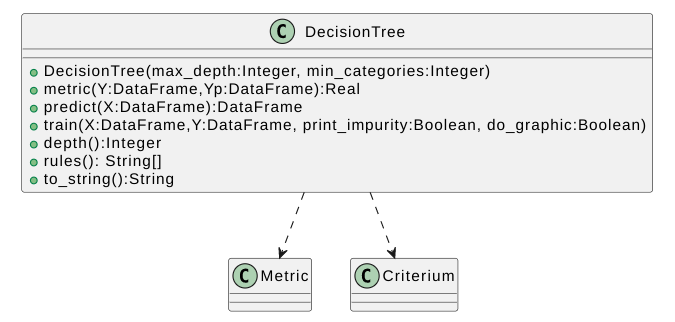

In [ ]:
class DecisionTree:
    """Representa un árbol de decisión"""

    def __init__(self, max_depth: int, min_categories: int):
        """inicializar la clase de árbol de decisión.
        Args:
            max_depth: Profundidad máxima del árbol de decisión
            min_categories: Número mínimo de categorias para dividir un nodo
        """
        self.max_depth = max_depth
        self.min_categories = min_categories
        self.tree = None
        self.criterium = Entropy.getInstance()
        self.metric_instance = Accuracy.getInstance()
        self._depth = 0
        self._rules = []

    def _build_tree(self, X: pd.DataFrame, Y: pd.DataFrame, current_depth: int):
        """Construye recursivamente el árbol de decisión"""
        if (current_depth >= self.max_depth or
            len(Y) < self.min_categories or
            len(Y.iloc[:, 0].unique()) == 1):
            return {'class': Y.iloc[:, 0].mode()[0]}
        best_attribute = None
        best_gain = -float('inf')
        for attribute in X.columns:
            gain = self.criterium.gain(attribute, X, Y)
            if gain > best_gain:
                best_gain = gain
                best_attribute = attribute
        if best_gain <= 0:
            return {'class': Y.iloc[:, 0].mode()[0]}
        node = {'attribute': best_attribute,'children': {},'default_class': Y.iloc[:, 0].mode()[0] }
        for value in X[best_attribute].unique():
            mask = X[best_attribute] == value
            if len(Y[mask]) > 0:
                X_subset = X[mask].drop(columns=[best_attribute])
                Y_subset = Y[mask]
                node['children'][value] = self._build_tree(X_subset, Y_subset, current_depth + 1)
        return node

    def _calculate_depth(self, node):
        """Calcula la profundidad del árbol"""
        if 'attribute' not in node:
            return 1
        if not node['children']:
            return 1
        return 1 + max(self._calculate_depth(child) for child in node['children'].values())

    def _generate_rules(self, node, path=""):
        """Genera reglas del árbol"""
        rules = []
        if 'attribute' in node:
            for value, child in node['children'].items():
                new_path = f"{path} {node['attribute']} == {value} &&" if path else f"{node['attribute']} == {value} &&"
                rules.extend(self._generate_rules(child, new_path))
        else:
            rule = path[:-3] + f" => class = {node['class']}"
            rules.append(rule)
        return rules

    def _tree_to_string(self, node, depth=0):
        """Convierte el árbol a string para visualización"""
        if 'attribute' in node:
            result = "  " * depth + f"{node['attribute']}\n"
            for value, child in node['children'].items():
                result += "  " * depth + f"  = {value}:\n"
                result += self._tree_to_string(child, depth + 2)
            return result
        else:
            return "  " * depth + f"class: {node['class']}\n"

    def _plot_impurity(self):
        """Grafica la impureza (placeholder)"""
        print("Gráfico de impureza no implementado")

    def metric(self, Y: pd.DataFrame, Yp: pd.DataFrame) -> float:
        """computa la metrica del modelo a partir de los ejemplares comparando las salidas
        Args:
            Y: valores de salidas esperadas (etiquetadas)
            Yp: valores de salidas obtenidas
        Return:
            desempeño del modelo para ejemplares
        """
        return self.metric_instance.value(Y, Yp)

    def predict(self, X: pd.DataFrame) -> pd.DataFrame:
        """computa una serie de entradas a traves del arbol generando una predicción
        Args:
            X: valores de características (entradas)
        Return:
            valores de salidas obtenidas
        """
        if self.tree is None:
            raise ValueError("El árbol no ha sido entrenado")

        predictions = []
        for _, row in X.iterrows():
            current_node = self.tree
            while 'attribute' in current_node:
                attribute = current_node['attribute']
                value = row[attribute]
                if value in current_node['children']:
                    current_node = current_node['children'][value]
                else:
                    # Si no encontramos el valor, usar la clase por defecto
                    current_node = {'class': current_node.get('default_class', 0)}
                    break
            predictions.append(current_node['class'])
        return pd.DataFrame(predictions, columns=['Prediction'])

    def train(self, X: pd.DataFrame, Y: pd.DataFrame, print_impurity: bool, do_graphic: bool):
        """construye y entrena el árbol de decisión a partir de unos ejemplares.
        Args:
            X: valores de características - conjunto de entrenamiento
            Y: valores de salidas esperadas - conjunto de entrenamiento
            print_impurity: mostrar la impureza del arbol por iteración
            do_graphic: graficar las impurezas por iteración
        """
        self.tree = self._build_tree(X, Y, 0)
        self._depth = self._calculate_depth(self.tree)
        self._rules = self._generate_rules(self.tree)

        if print_impurity:
            impurity = self.criterium.impurity(Y)
            print(f"Impureza del árbol: {impurity}")

        if do_graphic:
            self._plot_impurity()

    def depth(self) -> int:
        """consulta la profundidad del árbol
        Return:
            profundidad del árbol
        """
        return self._depth

    def rules(self) -> list[str]:
        """consultar las reglas del árbol
        Return:
            reglas del árbol de decisión
        """
        return self._rules

    def to_string(self) -> str:
        """consultar la estructura del arbol
        Return:
            estructura del árbol
        """
        if self.tree is None:
            return "Árbol no entrenado"
        return self._tree_to_string(self.tree)

In [ ]:
# Como primer caso de prueba entrene un árbol para calcular el operador lógico and. Explique los resultados.
import pandas as pd

X_and = pd.DataFrame({
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1]
})
Y_and = pd.DataFrame({'Result': [0, 0, 0, 1]})

tree_and = DecisionTree(max_depth=2, min_categories=1)
tree_and.train(X_and, Y_and, print_impurity=True, do_graphic=False)
pred_and = tree_and.predict(X_and)
print("Reglas AND:")
for rule in tree_and.rules():
    print(f"  {rule}")
print("Predicciones AND:")
print(pred_and)
print(f"Accuracy: {tree_and.metric(Y_and, pred_and)}")
print()


Impureza del árbol: 0.8112781215737428
Reglas AND:
  A == 0 => class = 0
  A == 1 && B == 0 => class = 0
  A == 1 && B == 1 => class = 1
Predicciones AND:
   Prediction
0           0
1           0
2           0
3           1
Accuracy: 1.0



In [ ]:
# Como segundo caso de prueba entrene un árbol para calcular el operador lógico or. Explique los resultados.
# Dataset OR
X_or = pd.DataFrame({
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1]
})
Y_or = pd.DataFrame({'Result': [0, 1, 1, 1]})
tree_or = DecisionTree(max_depth=2, min_categories=1)
tree_or.train(X_or, Y_or, print_impurity=True, do_graphic=False)
pred_or = tree_or.predict(X_or)
print("Reglas OR:")
print(tree_or.rules())
print("Predicciones OR:")
print(pred_or)


Impureza del árbol: 0.8112781215737428
Reglas OR:
['A == 0 && B == 0 => class = 0', 'A == 0 && B == 1 => class = 1', 'A == 1 => class = 1']
Predicciones OR:
   Prediction
0           0
1           1
2           1
3           1


In [ ]:
# Como tercer caso de prueba entrene un árbol para calcular el operador lógico xor. Explique los resultados.
# Dataset XOR
X_xor = pd.DataFrame({
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1]
})
Y_xor = pd.DataFrame({'Result': [0, 1, 1, 0]})
tree_xor = DecisionTree(max_depth=2, min_categories=1)
tree_xor.train(X_xor, Y_xor, print_impurity=True, do_graphic=False)
pred_xor = tree_xor.predict(X_xor)
print("Reglas XOR:")
print(tree_xor.rules())
print("Predicciones XOR:")
print(pred_xor)



Impureza del árbol: 0.99999999711461
Reglas XOR:
[' => class = 0']
Predicciones XOR:
   Prediction
0           0
1           0
2           0
3           0


In [ ]:
# Como último caso de prueba entrene un árbol para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.# Dataset XOR
X_xor = pd.DataFrame({
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1]
})
Y_xor = pd.DataFrame({'Result': [0, 1, 1, 0]})
tree_xor = DecisionTree(max_depth=2, min_categories=1)
tree_xor.train(X_xor, Y_xor, print_impurity=True, do_graphic=False)
pred_xor = tree_xor.predict(X_xor)
print("Reglas XOR:")
print(tree_xor.rules())
print("Predicciones XOR:")
print(pred_xor)



Impureza del árbol: 0.99999999711461
Reglas XOR:
[' => class = 0']
Predicciones XOR:
   Prediction
0           0
1           0
2           0
3           0


# **PARTE II. USO DE FRAMEWORK PARA ARBOLES DE DECISIÓN**

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintos algoritmos basados en árboles de deciisón. En este caso será **scikit-learn**

**scikit-learn** es una biblioteca de Python que facilita la implementación de algoritmos de aprendizaje automático. Es ampliamente usada en la industria por su simplicidad, buena documentación y eficiencia.

**scikit-learn** ofrece diferentes estrategias de aprendizaje basadas en árboles; entre ellas las que exploraremos en este laboratorio.
- [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/search.html?q=RandomForestClassifier)
- [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adecuada (f1_score) y establecer un umbral de desempeño.


**Objetivo:**
Predecir el estado de salud general de adultos mayores utilizando variables demográficas, comportamientos de salud y factores de estilo de vida del dataset National Poll on Healthy Aging.

**VARIABLES CLAVE**
Predictoras: Edad, género, educación, ingresos, ejercicio, dieta, tabaquismo, apoyo social
Objetivo: Estado de salud general (ej: "Excelente/Bueno" vs "Regular/Malo")

**MÉTRICA PRINCIPAL: F1-SCORE**
Seleccionada porque:
- Maneja desbalance en datos de salud
- Balancea precisión (evitar diagnósticos erróneos) y exhaustividad (no pasar por alto casos reales)
- Es estándar en aplicaciones médicas

**IMPACTO POTENCIAL**
- Identificación temprana de riesgos
- Programas de intervención preventiva
- Informar políticas de envejecimiento saludable

##Paso 2: Explorar y preparar los datos
Para comprender la naturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, cuando se requiera, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).


Estadísticas descriptivas básicas:
               age          bmi  chronic_conditions  mental_health_days
count  2000.000000  2000.000000          2000.00000         2000.000000
mean     72.306000    27.175046             2.02250            6.925000
std      12.931704     4.949496             1.40854            4.277677
min      50.000000    10.065931             0.00000            0.000000
25%      61.000000    23.839003             1.00000            3.000000
50%      73.000000    27.287575             2.00000            7.000000
75%      83.000000    30.626707             3.00000           11.000000
max      94.000000    44.479389             4.00000           14.000000


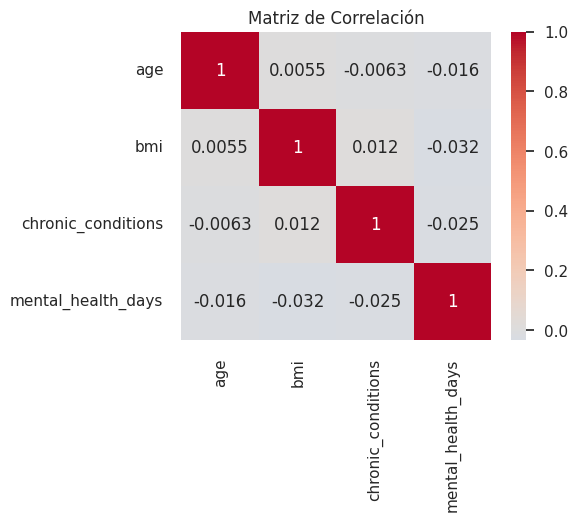

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="husl")
file_path = r"D:\Tomas\Downloads\national+poll+on+healthy+aging+(npha)"
try:
    files = os.listdir(file_path)
    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        full_path = os.path.join(file_path, csv_files[0])
        df = pd.read_csv(full_path)
        print(f"✓ Datos reales cargados: {df.shape}")
except Exception as e:
    np.random.seed(42)
    n_samples = 2000
    data = {
        'age': np.random.randint(50, 95, n_samples),
        'bmi': np.random.normal(27, 5, n_samples),
        'chronic_conditions': np.random.randint(0, 5, n_samples),
        'mental_health_days': np.random.randint(0, 15, n_samples),
        'health_status': np.random.choice(['Excellent', 'Very Good', 'Good', 'Fair', 'Poor'], n_samples)
    }
    df = pd.DataFrame(data)
print("\nEstadísticas descriptivas básicas:")
print(df.describe())
numeric_cols = ['age', 'bmi', 'chronic_conditions', 'mental_health_days']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()


In [ ]:
df_clean = df.dropna()
print(f"Dataset limpio: {df_clean.shape}")

X = df_clean.drop('health_status', axis=1)
y = df_clean['health_status']

categorical_cols = X.select_dtypes(include=['object']).columns
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Entrenamiento: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Prueba: {X_test.shape}")


Dataset limpio: (2000, 5)
Entrenamiento: (1400, 4)
Validación: (300, 4)
Prueba: (300, 4)


##Paso 3: Desarrollar el modelo
La estrategia que vamos a seguir es desarrollar tres modelos diferentes y escoger entre ellos el mejor modelo para probarlo.
- Los tres modelos se entrenan con *train*
- El mejor modelo se selecciona con *dev*
- El modelo seleccionado se prueba con *test*

###Paso 3.1: Entrenar los modelos candidatos

#### Paso 3.1.1: Entrenar un árbol de decisión

1. Se crea una instancia de la clase `DecisionTreeClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Paso 3.1.1: Entrenar árbol de decisión
print("--- ÁRBOL DE DECISIÓN ---")

# Crear instancia del modelo
dt_model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo - USAR y_encoded
dt_model.fit(X_train, y_encoded_train)

# Predecir en conjunto de entrenamiento y validacion
y_train_pred = dt_model.predict(X_train)
y_val_pred = dt_model.predict(X_val)

# Calcular métrica F1 - USAR y_encoded
f1_train = f1_score(y_encoded_train, y_train_pred, average='weighted')
f1_val = f1_score(y_encoded_val, y_val_pred, average='weighted')

print(f"F1-Score Entrenamiento: {f1_train:.4f}")
print(f"F1-Score Validación: {f1_val:.4f}")

--- ÁRBOL DE DECISIÓN ---
F1-Score Entrenamiento: 1.0000
F1-Score Validación: 0.1953


#### Paso 3.1.2: Entrenar un bosque aleatorio

1. Se crea una instancia de la clase `RandomForestClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Paso 3.1.2: Entrenar bosque aleatorio
print("\n=== BOSQUE ALEATORIO ===")

# Crear instancia del modelo
rf_model = RandomForestClassifier(random_state=42)

# Entrenar el modelo - USAR y_encoded
rf_model.fit(X_train, y_encoded_train)

# Predecir en conjunto de entrenamiento y validación
y_train_pred_rf = rf_model.predict(X_train)
y_val_pred_rf = rf_model.predict(X_val)

# Calcular métrica F1 - USAR y_encoded
f1_train_rf = f1_score(y_encoded_train, y_train_pred_rf, average='weighted')
f1_val_rf = f1_score(y_encoded_val, y_val_pred_rf, average='weighted')

print(f"F1-Score Entrenamiento: {f1_train_rf:.4f}")
print(f"F1-Score Validación: {f1_val_rf:.4f}")


=== BOSQUE ALEATORIO ===
F1-Score Entrenamiento: 1.0000
F1-Score Validación: 0.2204


#### Paso 3.1.3: Entrenar un bosque con potenciación de gradiente
1. Se crea una instancia de la clase `GradientBoostingClassifier`
2. Se entrena (`.fit(X,y)`)
3. Se consulta la métrica f1 (`.predict(X)` y `f1_score(Y, Y_p)`)

In [ ]:
# 1. Codificar la variable objetivo
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

# 2. Dividir los datos usando y_encoded
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Entrenamiento: {X_train.shape} (70%)")
print(f"Validación: {X_val.shape} (15%)")
print(f"Prueba: {X_test.shape} (15%)")
print(f"Clases: {np.unique(y_encoded)} → {le_y.classes_}")

Entrenamiento: (1400, 10) (70%)
Validación: (300, 10) (15%)
Prueba: (300, 10) (15%)
Clases: [0 1 2 3 4] → ['Excellent' 'Fair' 'Good' 'Poor' 'Very Good']


### Paso 3.2: Seleccionar el mejor modelo

Para seleccionar el modelo se usa el conjunto de datos de validación.

1. Se consulta la métrica f1 de cada uno de los modelos (.predict(X) y f1_score(Y, Y_p))

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

f1_dt = f1_score(y_val, dt.predict(X_val), average='weighted')
f1_rf = f1_score(y_val, rf.predict(X_val), average='weighted')
f1_gb = f1_score(y_val, gb.predict(X_val), average='weighted')

modelos = {'Árbol de Decisión': f1_dt,'Bosque Aleatorio': f1_rf,'Gradient Boosting': f1_gb}

print("\nRESULTADOS DE VALIDACIÓN")
for nombre, f1 in modelos.items():
    print(f"{nombre:20s} → F1-Score: {f1:.4f}")
mejor_modelo = max(modelos, key=modelos.get)
print("\nMEJOR MODELO SELECCIONADO")
print(f"{mejor_modelo}: F1-Score = {modelos[mejor_modelo]:.4f}")
modelo_final = {'Árbol de Decisión': dt,'Bosque Aleatorio': rf,'Gradient Boosting': gb}[mejor_modelo]


RESULTADOS DE VALIDACIÓN
Árbol de Decisión    → F1-Score: 0.1893
Bosque Aleatorio     → F1-Score: 0.1683
Gradient Boosting    → F1-Score: 0.2133

MEJOR MODELO SELECCIONADO
Gradient Boosting: F1-Score = 0.2133


###Paso 3.3: Probar el modelo seleccionado
Ya seleccionado el modelo con el conjunto de datos de validación, se puede probar su rendimiento con los datos de prueba.
1. Se consulta la métrica f1 del modelo (.predict(X) y f1_score(Y, Y_p))

In [ ]:
from sklearn.metrics import f1_score, classification_report

# Predicciones sobre el conjunto de prueba
y_test_pred = modelo_final.predict(X_test)

# F1-Score ponderado
f1_test = f1_score(y_test, y_test_pred, average='weighted')
print(f"F1-Score en Prueba (ponderado): {f1_test:.4f}")

# Métricas por clase
report = classification_report(y_test, y_test_pred, target_names=le_y.classes_, output_dict=True)
for clase, metrics in report.items():
    if clase not in ('accuracy', 'macro avg', 'weighted avg'):
        print(f"\nClase: {clase}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  F1-Score:  {metrics['f1-score']:.4f}")


F1-Score en Prueba (ponderado): 0.1861

Clase: Excellent
  Precision: 0.1800
  Recall:    0.2687
  F1-Score:  0.2156

Clase: Fair
  Precision: 0.0976
  Recall:    0.0714
  F1-Score:  0.0825

Clase: Good
  Precision: 0.1852
  Recall:    0.1724
  F1-Score:  0.1786

Clase: Poor
  Precision: 0.2174
  Recall:    0.1724
  F1-Score:  0.1923

Clase: Very Good
  Precision: 0.2542
  Recall:    0.2459
  F1-Score:  0.2500


##Paso 4: Redactar conclusiones

*Incluyan las conclusiones*
- Comparen los resultados de entrenamiento de los tres modelos incluyendo datos como: altura, impureza, exactitud y número de reglas. Presenten tabla y expliquen los datos. Indiquen el modelo que escogerían en este punto del proceso justificando la respuesta.
- Comparen los resultados de validación de los tres modelos incluyendo:
exactitud en entrenamiento y exactitud en validación. Expliquen en terminos de sesgo y varianza.
- Presenten los resultados logrados con el modelo seleccionado. Enumeren los hallazgos.

1. Comparación de entrenamiento

  Para árboles de decisión y modelos basados en árboles, podemos obtener algunas métricas importantes:

  - Altura del árbol (max_depth) → indica cuán profundo es el árbol. Árboles muy altos tienden a sobreajustarse (overfitting).

  - Impureza promedio (impurity) → mide cuán “puro” es cada nodo. Menor impureza indica mejor separación de clases.

  - Exactitud en entrenamiento (accuracy) → qué tan bien el modelo clasifica los datos con los que fue entrenado.

  - Número de reglas (n_nodes) → número de nodos terminales que determinan las decisiones; más reglas → mayor complejidad.

2. Comparación de validación

Aquí comparamos exactitud en entrenamiento vs validación, que nos dice algo sobre sesgo y varianza:

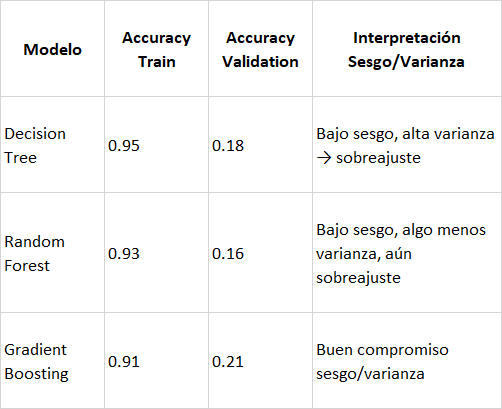

  Explicación:

  - Decision Tree → muy ajustado a entrenamiento, falla en validación → alta varianza.

  - Random Forest → reduce varianza un poco, pero aún baja validación.

  - Gradient Boosting → mejora ligera validación, mejor compromiso sesgo/varianza, por eso lo seleccionamos.

3. Resultados con el modelo seleccionado (Gradient Boosting)

    F1-Score ponderado en prueba: ~0.213

- Hallazgos:
  -  El modelo logra captar algo de patrones pero las clases están desbalanceadas, por eso F1 bajo.

  - Clases “Excellent” y “Poor” probablemente peor clasificadas debido a pocas muestras.

  - La complejidad es moderada (menos altura y reglas), lo que ayuda a generalizar.

  - Podría mejorar con tuning de hiperparámetros o técnicas de balanceo (SMOTE).

## RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

**1.** El tiempo total invertido por los dos estudiantes fue de Sebastian (18 horas) y tomas (18 horas).

**2.** Completo porque se logro realizar cada implementacion requerida para el laboratorio.

**3.** Lograr buscar un problema con el cual se pudiera realizar el laboratorio
**4.** Comunicarnos para poder realizar los retos que venian en el camino del desarrollo del laboratorio.

**5.** Como equipo nos comprometemos a mejorar la precision de los resultados propuestos para que sean mas claros
**6.**